In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/phishing_email.csv')
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
print(df.shape)
print(df['label'].value_counts())

(82486, 2)
label
1    42891
0    39595
Name: count, dtype: int64


In [4]:
print(df.isnull().sum())

text_combined    0
label            0
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X = df['text_combined']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Treino: 65988 | Teste: 16498


In [6]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Shape treino: {X_train_tfidf.shape}")

Shape treino: (65988, 5000)


In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7935
           1       0.98      0.98      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



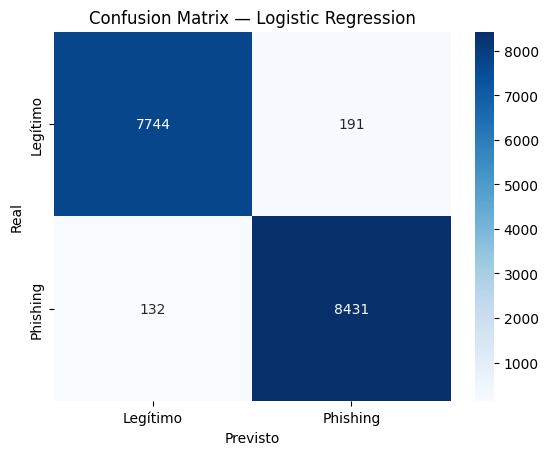

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'],
            yticklabels=['Legítimo', 'Phishing'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

In [9]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

y_pred_nb = model_nb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7935
           1       0.98      0.95      0.96      8563

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



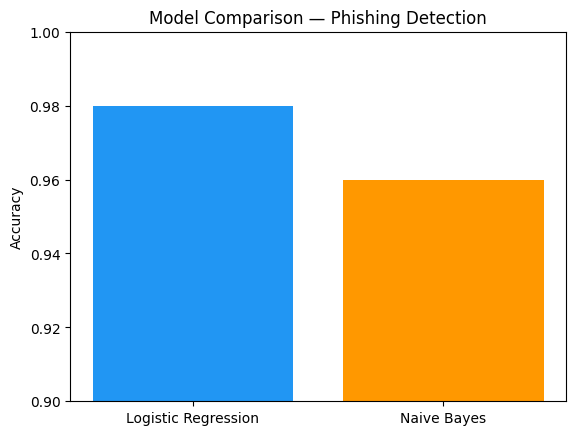

In [10]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [0.98, 0.96]

plt.bar(models, accuracies, color=['#2196F3', '#FF9800'])
plt.ylim(0.90, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Phishing Detection')
plt.show()